In [2]:
from sqlalchemy import create_engine
import pandas as pd

username = "postgres"
password = "3968"
host = "localhost"
port = "5432"
database = "ecommerce_analytics"

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

In [3]:
pd.read_sql("SELECT COUNT(*) FROM orders;", engine)

,count
0,50000


In [4]:
customers = pd.read_sql('SELECT * FROM customers;', engine)
products = pd.read_sql('SELECT * FROM products;', engine)
orders = pd.read_sql('SELECT * FROM orders;', engine)
order_items = pd.read_sql('SELECT * FROM order_items;', engine)
payments = pd.read_sql('SELECT * FROM payments;', engine)
returns = pd.read_sql('SELECT * FROM returns;', engine)

print(customers.shape, products.shape, orders.shape, order_items.shape, payments.shape, returns.shape)

(12000, 8) (500, 7) (50000, 5) (109727, 8) (50000, 3) (3607, 4)


In [5]:
order_items.head(3)

,order_id,product_id,quantity,unit_price,discount_pct,gross_amount,discount_amount,net_amount
0,ORD000001,PROD0401,1,422.18,20,422.18,84.44,337.74
1,ORD000002,PROD0428,2,2783.65,0,5567.30,0.00,5567.30
2,ORD000002,PROD0131,2,3412.30,20,6824.60,1364.92,5459.68


In [6]:
customers.head(10)

,customer_id,customer_name,gender,age,city,state,signup_date,acquisition_channel
0,CUST00119,Rahul Chauhan,Male,NaN,Kolkata,West Bengal,2024-06-11,Social Media
1,CUST00156,Siddharth Desai,Male,NaN,Ahmedabad,Gujarat,2025-01-16,Paid Search
2,CUST00159,Karthik Bansal,Male,NaN,Pune,Maharashtra,2025-03-03,Organic Search
3,CUST00167,Karthik Bansal,Male,NaN,Surat,Gujarat,2025-05-25,Direct
4,CUST00264,Kunal Verma,Male,NaN,Kanpur,Uttar Pradesh,2023-07-25,Direct
5,CUST00243,Krishna Iyer,Male,47.0,Surat,Gujarat,2023-11-11,Direct
6,CUST00573,Priya Iyer,Female,NaN,Gurugram,Haryana,2024-07-30,Social Media
7,CUST00622,Saanvi Menon,Female,NaN,Ahmedabad,Gujarat,2024-08-06,Organic Search
8,CUST00673,Gaurav Bansal,Male,NaN,Surat,Gujarat,2025-09-29,Social Media
9,CUST00830,Aman Singh,Male,NaN,Bengaluru,Karnataka,2023-12-05,Paid Search


In [7]:
products.head(3)

,product_id,product_name,category,subcategory,brand,unit_price,cost_price
0,PROD0001,UrbanNest Ceiling Fan 538,Home & Kitchen,Appliances,UrbanNest,939.0,649.13
1,PROD0002,LivWell Curtain Set 994,Home & Kitchen,Home Decor,LivWell,449.0,229.97
2,PROD0003,Chikoo Sandals 853,Fashion,Footwear,Chikoo,1189.0,576.67


In [8]:
payments.head(3)

,order_id,payment_method,payment_status
0,ORD000001,UPI,Paid
1,ORD000002,Credit Card,Paid
2,ORD000003,Debit Card,Paid


In [9]:
orders.head(3)

,order_id,customer_id,order_date,order_status,shipping_city
0,ORD000001,CUST00856,2025-03-27,Delivered,Jaipur
1,ORD000002,CUST06976,2024-01-30,Delivered,Thane
2,ORD000003,CUST09405,2025-12-08,Delivered,Bengaluru


In [10]:
returns.head(3)

,order_id,return_date,return_reason,refund_amount
0,ORD000011,2025-12-09,Changed Mind,274.60
1,ORD000022,2025-10-11,Damaged Product,2979.32
2,ORD000037,2025-10-23,Quality Issue,5293.89


In [11]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109727 entries, 0 to 109726
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_id         109727 non-null  object 
 1   product_id       109727 non-null  object 
 2   quantity         109727 non-null  int64  
 3   unit_price       109727 non-null  float64
 4   discount_pct     109727 non-null  int64  
 5   gross_amount     109727 non-null  float64
 6   discount_amount  109727 non-null  float64
 7   net_amount       109727 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 6.7+ MB


In [12]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          12000 non-null  object 
 1   customer_name        12000 non-null  object 
 2   gender               11940 non-null  object 
 3   age                  11880 non-null  float64
 4   city                 12000 non-null  object 
 5   state                12000 non-null  object 
 6   signup_date          12000 non-null  object 
 7   acquisition_channel  11760 non-null  object 
dtypes: float64(1), object(7)
memory usage: 750.1+ KB


In [13]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    500 non-null    object 
 1   product_name  500 non-null    object 
 2   category      500 non-null    object 
 3   subcategory   500 non-null    object 
 4   brand         500 non-null    object 
 5   unit_price    500 non-null    float64
 6   cost_price    500 non-null    float64
dtypes: float64(2), object(5)
memory usage: 27.5+ KB


In [14]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   order_id        50000 non-null  object
 1   payment_method  50000 non-null  object
 2   payment_status  50000 non-null  object
dtypes: object(3)
memory usage: 1.1+ MB


In [15]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   order_id       50000 non-null  object
 1   customer_id    50000 non-null  object
 2   order_date     50000 non-null  object
 3   order_status   50000 non-null  object
 4   shipping_city  50000 non-null  object
dtypes: object(5)
memory usage: 1.9+ MB


In [16]:
returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3607 entries, 0 to 3606
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       3607 non-null   object 
 1   return_date    3607 non-null   object 
 2   return_reason  3607 non-null   object 
 3   refund_amount  3607 non-null   float64
dtypes: float64(1), object(3)
memory usage: 112.8+ KB


### CHANGE THE DATATYPE

In [17]:
# in customers table we have to change the datatype of signup_date to datetime
customers['signup_date'] = pd.to_datetime(customers['signup_date'])

In [18]:
# in orders table we have to change the datatype of order_date to datetime
orders['order_date'] = pd.to_datetime(orders['order_date'])

In [19]:
# in returns table we have to change the datatype of return_date to datetime
returns['return_date'] = pd.to_datetime(returns['return_date'])

In [20]:
customers['age'] = customers['age'].fillna(customers['age'].median()).astype(int)

### FILLING THE NULL VALUES

In [21]:
customers['gender'].unique()

array(['Male', 'Female', None], dtype=object)

In [22]:
customers['gender'] = customers['gender'].fillna('unknown')

In [23]:
customers['gender'].unique()

array(['Male', 'Female', 'unknown'], dtype=object)

In [24]:
customers['acquisition_channel'] = customers['acquisition_channel'].fillna('Unknown')

In [25]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_id          12000 non-null  object        
 1   customer_name        12000 non-null  object        
 2   gender               12000 non-null  object        
 3   age                  12000 non-null  int64         
 4   city                 12000 non-null  object        
 5   state                12000 non-null  object        
 6   signup_date          12000 non-null  datetime64[ns]
 7   acquisition_channel  12000 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 750.1+ KB


In [26]:
returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3607 entries, 0 to 3606
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       3607 non-null   object        
 1   return_date    3607 non-null   datetime64[ns]
 2   return_reason  3607 non-null   object        
 3   refund_amount  3607 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 112.8+ KB


In [27]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       50000 non-null  object        
 1   customer_id    50000 non-null  object        
 2   order_date     50000 non-null  datetime64[ns]
 3   order_status   50000 non-null  object        
 4   shipping_city  50000 non-null  object        
dtypes: datetime64[ns](1), object(4)
memory usage: 1.9+ MB


# ANALYSIS

### Q1 What is the total revenue (gross vs. net — Delivered vs. Cancelled/Returned)?

In [28]:
# order-level revenue table banate hain (clean data ke saath)
order_revenue = order_items.merge(orders[['order_id', 'customer_id', 'order_date', 'order_status']], on='order_id')
order_revenue.head()

,order_id,product_id,quantity,unit_price,discount_pct,gross_amount,discount_amount,net_amount,customer_id,order_date,order_status
0,ORD000001,PROD0401,1,422.18,20,422.18,84.44,337.74,CUST00856,2025-03-27,Delivered
1,ORD000002,PROD0428,2,2783.65,0,5567.30,0.00,5567.30,CUST06976,2024-01-30,Delivered
2,ORD000002,PROD0131,2,3412.30,20,6824.60,1364.92,5459.68,CUST06976,2024-01-30,Delivered
3,ORD000002,PROD0442,2,1506.29,0,3012.58,0.00,3012.58,CUST06976,2024-01-30,Delivered
4,ORD000002,PROD0465,3,8581.27,0,25743.81,0.00,25743.81,CUST06976,2024-01-30,Delivered


In [29]:
# Q1: Gross vs Net Revenue (order_status wise)
revenue_by_status = order_revenue.groupby('order_status')['net_amount'].sum().sort_values(ascending=False)
revenue_by_status_pct = (revenue_by_status / revenue_by_status.sum() * 100).round(2)

summary = pd.DataFrame({
    'revenue': revenue_by_status.round(2),
    'pct_of_total': revenue_by_status_pct
})
print(summary)

                   revenue  pct_of_total
order_status                            
Delivered     7.139575e+08         78.55
Cancelled     6.964939e+07          7.66
Shipped       6.312295e+07          6.94
Returned      6.217382e+07          6.84


In [30]:
pd.options.display.float_format = '{:,.2f}'.format
print(summary)

                    revenue  pct_of_total
order_status                             
Delivered    713,957,488.07         78.55
Cancelled     69,649,388.70          7.66
Shipped       63,122,953.67          6.94
Returned      62,173,815.26          6.84


### Q2 What is the month-over-month revenue trend?

In [31]:
delivered = order_revenue[order_revenue['order_status'] == 'Delivered'].copy()
delivered['month'] = delivered['order_date'].dt.to_period('M').astype(str)

monthly_revenue = delivered.groupby('month')['net_amount'].sum().reset_index()
print(monthly_revenue)

      month    net_amount
0   2024-01  7,442,310.22
1   2024-02  7,731,981.46
2   2024-03  9,373,378.14
3   2024-04 10,121,983.51
4   2024-05 12,798,469.82
5   2024-06 13,065,218.36
6   2024-07 14,286,521.00
7   2024-08 16,890,928.98
8   2024-09 14,933,926.66
9   2024-10 28,346,955.58
10  2024-11 23,898,051.35
11  2024-12 27,930,051.12
12  2025-01 23,987,365.10
13  2025-02 23,288,190.72
14  2025-03 27,180,257.58
15  2025-04 28,610,699.39
16  2025-05 34,755,827.60
17  2025-06 37,855,569.31
18  2025-07 38,135,695.64
19  2025-08 47,211,452.17
20  2025-09 43,297,947.69
21  2025-10 85,561,358.41
22  2025-11 66,138,423.26
23  2025-12 71,114,925.00


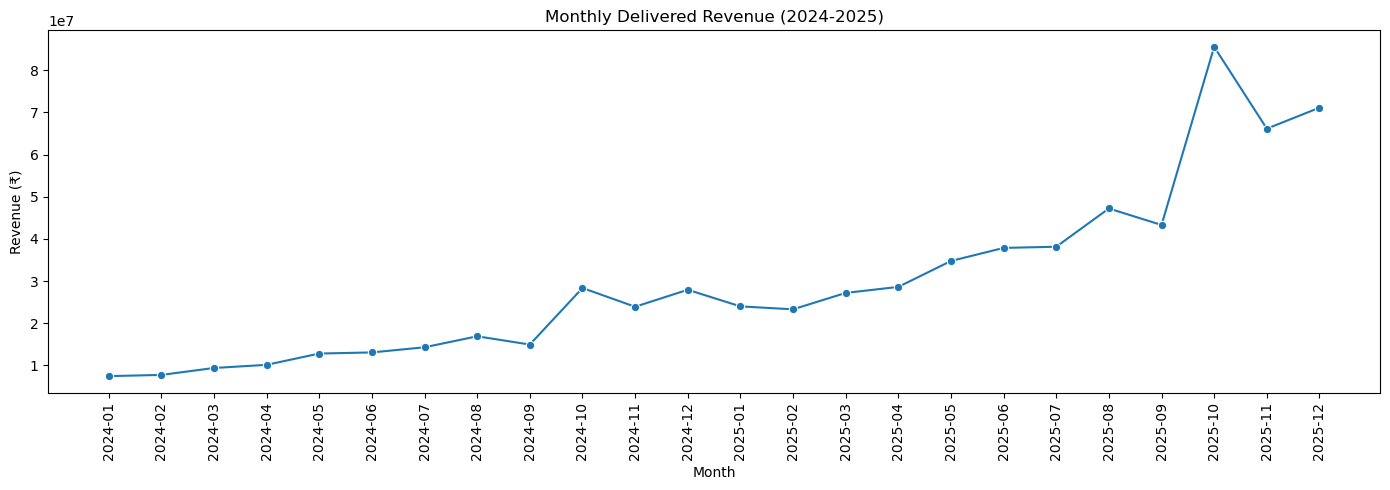

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,5))
sns.lineplot(data=monthly_revenue, x='month', y='net_amount', marker='o')
plt.xticks(rotation=90)
plt.title('Monthly Delivered Revenue (2024-2025)')
plt.ylabel('Revenue (₹)')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

### Q4 What percentage of customers are repeat buyers vs. one-time vs. never-ordered?

In [33]:
# Har customer ne kitne orders diye, count karo
customer_order_counts = orders.groupby('customer_id').size().reset_index(name='order_count')

# Saare customers ke saath merge karo (jinhone kabhi order nahi kiya, unke liye bhi row aani chahiye)
all_customers_orders = customers[['customer_id']].merge(customer_order_counts, on='customer_id', how='left')
all_customers_orders['order_count'] = all_customers_orders['order_count'].fillna(0).astype(int)

# Segment banao
def segment(count):
    if count == 0:
        return 'Never Ordered'
    elif count == 1:
        return 'One-Time Buyer'
    else:
        return 'Repeat Buyer'

all_customers_orders['segment'] = all_customers_orders['order_count'].apply(segment)

segment_summary = all_customers_orders['segment'].value_counts()
segment_pct = (segment_summary / segment_summary.sum() * 100).round(2)

print(pd.DataFrame({'count': segment_summary, 'pct': segment_pct}))

                count   pct
segment                    
Repeat Buyer     6475 53.96
Never Ordered    3740 31.17
One-Time Buyer   1785 14.88


### Q5 Who are the top 10 customers by lifetime value (LTV)?

In [34]:
customer_ltv = order_revenue[order_revenue['order_status'] == 'Delivered'].groupby('customer_id')['net_amount'].sum().sort_values(ascending=False).head(10)

top10_ltv = customer_ltv.reset_index().merge(customers[['customer_id', 'customer_name', 'city']], on='customer_id')
top10_ltv.columns = ['customer_id', 'lifetime_value', 'customer_name', 'city']
print(top10_ltv[['customer_id', 'customer_name', 'city', 'lifetime_value']])

  customer_id      customer_name       city  lifetime_value
0   CUST08779  Abhishek Banerjee      Delhi    1,771,861.42
1   CUST07762      Anjali Sharma       Agra    1,366,498.98
2   CUST05055       Rajesh Gupta     Mumbai    1,303,894.67
3   CUST07367  Abhishek Banerjee   Vadodara    1,264,597.01
4   CUST04645       Ananya Menon      Thane    1,178,644.58
5   CUST07716    Abhishek Sharma     Kanpur    1,177,479.20
6   CUST00019          Swati Rao     Nashik    1,169,581.06
7   CUST02182        Kiran Kumar  Hyderabad    1,141,721.24
8   CUST00659     Radhika Tiwari     Mumbai    1,112,705.61
9   CUST08027    Vikram Banerjee       Pune    1,083,436.55


### Q6 Which acquisition channel brings in the highest-revenue customers?

In [35]:
# Customer LTV nikaalo (Delivered orders se), phir unke acquisition_channel se jodo
customer_ltv_all = order_revenue[order_revenue['order_status'] == 'Delivered'].groupby('customer_id')['net_amount'].sum().reset_index()
customer_ltv_all.columns = ['customer_id', 'lifetime_value']

ltv_with_channel = customer_ltv_all.merge(customers[['customer_id', 'acquisition_channel']], on='customer_id')

channel_summary = ltv_with_channel.groupby('acquisition_channel').agg(
    num_customers=('customer_id', 'count'),
    total_revenue=('lifetime_value', 'sum'),
    avg_ltv_per_customer=('lifetime_value', 'mean')
).round(2).sort_values('total_revenue', ascending=False)

print(channel_summary)

                     num_customers  total_revenue  avg_ltv_per_customer
acquisition_channel                                                    
Organic Search                2546 235,313,751.71             92,424.88
Paid Search                   1541 141,577,304.42             91,873.66
Social Media                  1467 136,859,869.76             93,292.34
Direct                         976  84,679,661.09             86,761.95
Referral                       624  56,628,597.75             90,750.96
Email                          456  43,630,106.67             95,680.06
Unknown                        155  15,268,196.67             98,504.49


### Q7 Which category/subcategory generates the highest revenue?

In [36]:
# order_items ko products ke saath jodo taaki category mile
oi_with_product = order_items.merge(products[['product_id', 'category', 'subcategory']], on='product_id')
oi_with_status = oi_with_product.merge(orders[['order_id', 'order_status']], on='order_id')

delivered_items = oi_with_status[oi_with_status['order_status'] == 'Delivered']

category_revenue = delivered_items.groupby('category')['net_amount'].sum().sort_values(ascending=False)
category_pct = (category_revenue / category_revenue.sum() * 100).round(2)

print(pd.DataFrame({'revenue': category_revenue.round(2), 'pct': category_pct}))

                        revenue   pct
category                             
Electronics      462,703,346.80 64.81
Home & Kitchen    92,054,023.67 12.89
Sports & Fitness  66,119,555.57  9.26
Fashion           64,592,058.79  9.05
Beauty            21,016,313.79  2.94
Books              7,472,189.45  1.05


In [37]:
subcategory_revenue = delivered_items.groupby(['category', 'subcategory'])['net_amount'].sum().sort_values(ascending=False).head(10)
print(subcategory_revenue)

category          subcategory
Electronics       Audio         211,844,101.52
                  Laptops        98,547,148.08
                  Smartphones    86,731,304.91
                  Accessories    65,580,792.29
Sports & Fitness  Outdoor        35,593,195.81
Home & Kitchen    Kitchen        33,369,060.75
                  Appliances     22,910,737.46
Fashion           Men            19,467,460.62
Home & Kitchen    Furniture      18,834,441.22
Sports & Fitness  Fitness        18,292,324.50
Name: net_amount, dtype: float64


### Q8 What are the top 10 bestselling products (by revenue and by quantity)?

In [38]:
# By revenue
top10_by_revenue = delivered_items.groupby(['product_id']).agg(
    total_revenue=('net_amount', 'sum'),
    total_quantity=('quantity', 'sum')
).sort_values('total_revenue', ascending=False).head(10)

top10_by_revenue = top10_by_revenue.merge(products[['product_id', 'product_name', 'category', 'subcategory']], on='product_id')
print(top10_by_revenue[['product_name', 'category', 'subcategory', 'total_revenue', 'total_quantity']])

                     product_name          category  subcategory  \
0  Samsonic Bluetooth Speaker 317       Electronics        Audio   
1            Skyline Notebook 581       Electronics      Laptops   
2             Nexo Smartphone 250       Electronics  Smartphones   
3    KitchenKing Cookware Set 470    Home & Kitchen      Kitchen   
4         Samsonic Headphones 410       Electronics        Audio   
5            BrightWave Phone 474       Electronics  Smartphones   
6                 Voltek Case 814       Electronics  Accessories   
7              Samsonic Phone 519       Electronics  Smartphones   
8           Voltek Headphones 255       Electronics        Audio   
9        FitPro Trekking Pole 137  Sports & Fitness      Outdoor   

   total_revenue  total_quantity  
0 108,797,396.21            1920  
1  39,755,713.41            1160  
2  21,112,681.05             437  
3  20,786,441.89            1552  
4  17,743,055.04             732  
5  17,647,705.44             493  
6  17,

In [39]:
top10_by_quantity = delivered_items.groupby(['product_id']).agg(
    total_quantity=('quantity', 'sum'),
    total_revenue=('net_amount', 'sum')
).sort_values('total_quantity', ascending=False).head(10)

top10_by_quantity = top10_by_quantity.merge(products[['product_id', 'product_name', 'category', 'subcategory']], on='product_id')
print(top10_by_quantity[['product_name', 'category', 'subcategory', 'total_quantity', 'total_revenue']])

                     product_name          category  subcategory  \
0       GlowUp Compact Powder 123            Beauty       Makeup   
1  Samsonic Bluetooth Speaker 317       Electronics        Audio   
2            Skyline Notebook 485       Electronics      Laptops   
3        Trendify Men's Jeans 649           Fashion          Men   
4        FitPro Trekking Pole 137  Sports & Fitness      Outdoor   
5      Trendify Women's Kurti 251           Fashion        Women   
6   OmniTech Wireless Earbuds 632       Electronics        Audio   
7        Chikoo Men's T-Shirt 852           Fashion          Men   
8               Samsonic Case 207       Electronics  Accessories   
9    KitchenKing Cookware Set 470    Home & Kitchen      Kitchen   

   total_quantity  total_revenue  
0            2040   1,636,077.14  
1            1920 108,797,396.21  
2            1918  11,169,650.18  
3            1876   1,455,758.44  
4            1856  14,539,063.74  
5            1849   1,188,043.92  
6     

### Q9 Which products are high-margin vs. low-margin?

In [40]:
products['margin_pct'] = ((products['unit_price'] - products['cost_price']) / products['unit_price'] * 100).round(2)

print("Top 5 Highest Margin Products:")
print(products.nlargest(5, 'margin_pct')[['product_name', 'category', 'unit_price', 'cost_price', 'margin_pct']])

print("\nBottom 5 Lowest Margin Products:")
print(products.nsmallest(5, 'margin_pct')[['product_name', 'category', 'unit_price', 'cost_price', 'margin_pct']])

print("\nAverage margin % by category:")
print(products.groupby('category')['margin_pct'].mean().round(2).sort_values(ascending=False))

Top 5 Highest Margin Products:
                        product_name category  unit_price  cost_price  \
485           Chikoo Men's Shirt 108  Fashion      299.00      105.37   
462  BrightMind Books Dictionary 915    Books      539.00      190.12   
180           Metro Wear Charger 546  Fashion    3,699.00    1,305.42   
384       StorySpring Dictionary 381    Books      239.00       84.45   
298       Trendify Women's Dress 664  Fashion    1,309.00      464.20   

     margin_pct  
485       64.76  
462       64.73  
180       64.71  
384       64.67  
298       64.54  

Bottom 5 Lowest Margin Products:
                      product_name          category  unit_price  cost_price  \
18              PureSkin Kajal 891            Beauty      669.00      466.60   
245              Samsonic Case 726       Electronics    3,049.00    2,122.31   
150         FitPro Track Pants 415  Sports & Fitness    2,169.00    1,507.52   
330  StorySpring Mystery Novel 510             Books      669.00    

### Q10 How does discount % affect order value?

In [41]:
discount_impact = delivered_items.groupby('discount_pct').agg(
    num_items=('order_id', 'count'),
    avg_net_amount=('net_amount', 'mean'),
    total_revenue=('net_amount', 'sum')
).round(2)

print(discount_impact)

              num_items  avg_net_amount  total_revenue
discount_pct                                          
0                 32622        8,918.12 290,927,030.65
5                 15706        8,468.46 133,005,653.11
10                13843        8,434.85 116,763,577.76
15                10317        7,570.05  78,100,246.00
20                 7770        7,042.81  54,722,623.73
25                 4333        6,950.50  30,116,502.95
30                 1750        5,898.20  10,321,853.87


### Q11: Most popular payment method

In [42]:
payment_method_dist = payments['payment_method'].value_counts()
payment_method_pct = (payment_method_dist / payment_method_dist.sum() * 100).round(2)
print("Payment Method Distribution:")
print(pd.DataFrame({'count': payment_method_dist, 'pct': payment_method_pct}))

Payment Method Distribution:
                  count   pct
payment_method               
UPI               18006 36.01
Credit Card        8945 17.89
Cash on Delivery   8573 17.15
Debit Card         6871 13.74
Net Banking        4006  8.01
Wallet             3599  7.20


### Q12: Which payment method has highest Failed/Refunded rate

In [46]:
payment_status_by_method = pd.crosstab(payments['payment_method'], payments['payment_status'], normalize='index') * 100
print("\nPayment Status % by Method:")
print(payment_status_by_method.round(2))


Payment Status % by Method:
payment_status    Failed  Paid  Refunded
payment_method                          
Cash on Delivery    6.50 83.04     10.46
Credit Card         6.20 83.66     10.14
Debit Card          6.29 83.25     10.46
Net Banking         6.71 83.25     10.03
UPI                 6.50 83.23     10.27
Wallet              6.39 83.86      9.75


### Q13 What is the overall and category-wise return rate?

In [51]:
total_delivered_returned_orders = orders[orders['order_status'].isin(['Delivered', 'Returned'])].shape[0]
returned_orders = orders[orders['order_status'] == 'Returned'].shape[0]
overall_return_rate = (returned_orders / total_delivered_returned_orders * 100)
print(f"Overall Return Rate: {overall_return_rate}%")

Overall Return Rate: 7.7933963813859615%


In [47]:
returned_order_ids = orders[orders['order_status'] == 'Returned']['order_id']
returned_items = order_items[order_items['order_id'].isin(returned_order_ids)].merge(
    products[['product_id', 'category']], on='product_id')

category_return_revenue = returned_items.groupby('category')['net_amount'].sum().sort_values(ascending=False)
print("\nReturned Revenue by Category:")
print(category_return_revenue)


Returned Revenue by Category:
category
Electronics        39,958,358.18
Home & Kitchen      8,545,946.59
Sports & Fitness    5,654,313.23
Fashion             5,486,851.13
Beauty              1,920,345.03
Books                 608,001.10
Name: net_amount, dtype: float64


In [52]:
category_total_revenue = delivered_items.groupby('category')['net_amount'].sum()
category_return_revenue_series = category_return_revenue

category_return_rate = (category_return_revenue_series / category_total_revenue * 100).round(2).sort_values(ascending=False)
print("Return Rate % by Category (returned revenue / delivered revenue):")
print(category_return_rate)

Return Rate % by Category (returned revenue / delivered revenue):
category
Home & Kitchen     9.28
Beauty             9.14
Electronics        8.64
Sports & Fitness   8.55
Fashion            8.49
Books              8.14
Name: net_amount, dtype: float64


### Q14 What is the most common return reason?

In [53]:
return_reason_dist = returns['return_reason'].value_counts()
return_reason_pct = (return_reason_dist / return_reason_dist.sum() * 100).round(2)
print(pd.DataFrame({'count': return_reason_dist, 'pct': return_reason_pct}))

                 count   pct
return_reason               
Damaged Product    798 22.12
Changed Mind       681 18.88
Quality Issue      667 18.49
Size/Fit Issue     576 15.97
Wrong Product      527 14.61
Late Delivery      358  9.93


### Q15 How much revenue is lost due to cancelled orders?

In [54]:
cancelled_orders_revenue = order_revenue[order_revenue['order_status'] == 'Cancelled']['net_amount'].sum()
total_gross_revenue = order_revenue['net_amount'].sum()

print(f"Revenue lost to Cancellations: ₹{cancelled_orders_revenue:,.2f}")
print(f"As % of total gross revenue: {(cancelled_orders_revenue/total_gross_revenue*100):.2f}%")

# bonus: total loss including returns (refunded amount)
total_refund_amount = returns['refund_amount'].sum()
print(f"\nTotal refund amount paid out (Returns): ₹{total_refund_amount:,.2f}")
print(f"Combined Cancelled + Refunded loss: ₹{cancelled_orders_revenue + total_refund_amount:,.2f}")

Revenue lost to Cancellations: ₹69,649,388.70
As % of total gross revenue: 7.66%

Total refund amount paid out (Returns): ₹56,196,935.69
Combined Cancelled + Refunded loss: ₹125,846,324.39


### Q16 Which cities/states generate the highest revenue?

In [55]:
oi_with_customer = order_revenue[order_revenue['order_status'] == 'Delivered'].merge(
    customers[['customer_id', 'city', 'state']], on='customer_id')

top_cities = oi_with_customer.groupby('city')['net_amount'].sum().sort_values(ascending=False).head(10)
print("Top 10 Cities by Revenue:")
print(top_cities)

top_states = oi_with_customer.groupby('state')['net_amount'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 States by Revenue:")
print(top_states)

Top 10 Cities by Revenue:
city
Mumbai      75,753,349.23
Delhi       74,767,686.56
Bengaluru   61,827,446.45
Hyderabad   46,044,084.64
Ahmedabad   41,463,257.07
Pune        40,114,966.84
Kolkata     36,747,684.80
Chennai     35,819,015.34
Jaipur      28,283,171.85
Lucknow     24,200,418.85
Name: net_amount, dtype: float64

Top 10 States by Revenue:
state
Maharashtra      148,614,919.41
Gujarat           80,033,714.03
Delhi             74,767,686.56
Uttar Pradesh     74,476,770.22
Karnataka         61,827,446.45
Tamil Nadu        47,850,648.97
Telangana         46,044,084.64
West Bengal       36,747,684.80
Madhya Pradesh    33,165,926.03
Rajasthan         28,283,171.85
Name: net_amount, dtype: float64


In [59]:
import os
os.makedirs('../dashboards', exist_ok=True)
print("Folder ready:", os.path.exists('../dashboards'))

Folder ready: True


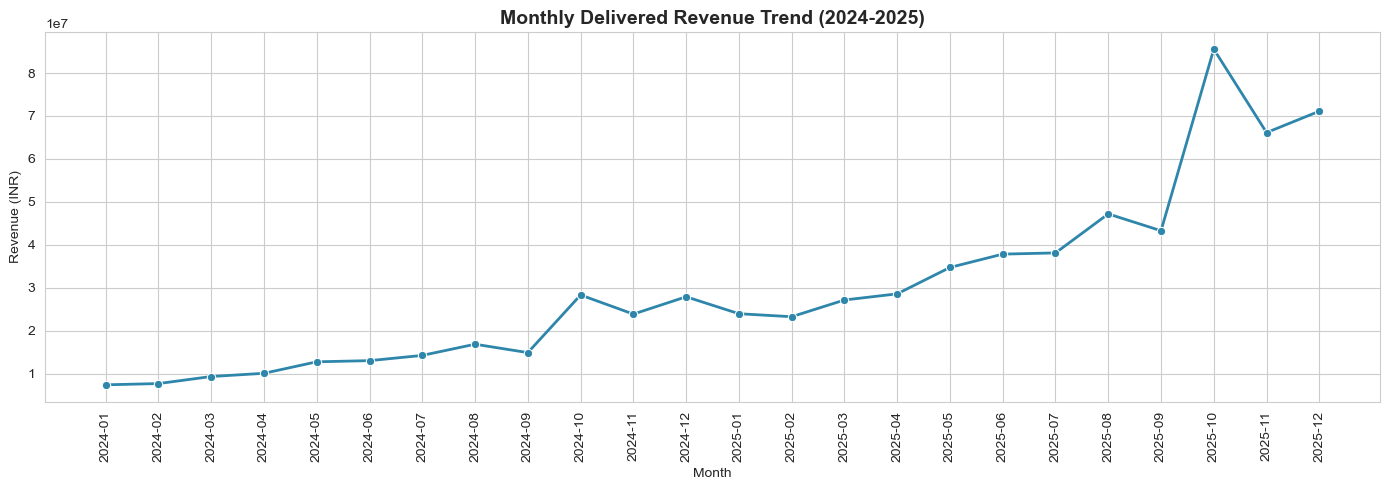

In [61]:
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

fig, ax = plt.subplots(figsize=(14,5))
sns.lineplot(data=monthly_revenue, x='month', y='net_amount', marker='o', color='#2E86AB', linewidth=2, ax=ax)
ax.set_title('Monthly Delivered Revenue Trend (2024-2025)', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (INR)')
ax.set_xlabel('Month')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('../dashboards/01_monthly_revenue_trend.png', dpi=150)
plt.show()

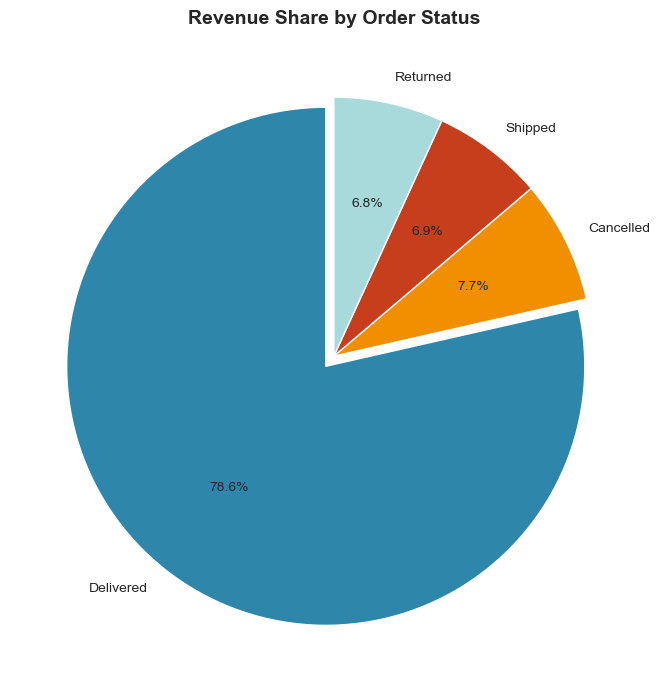

In [62]:
fig, ax = plt.subplots(figsize=(7,7))
colors = ['#2E86AB', '#F18F01', '#C73E1D', '#A8DADC']
ax.pie(revenue_by_status, labels=revenue_by_status.index, autopct='%1.1f%%',
       colors=colors, startangle=90, explode=[0.05,0,0,0])
ax.set_title('Revenue Share by Order Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../dashboards/02_revenue_by_status.png', dpi=150)
plt.show()

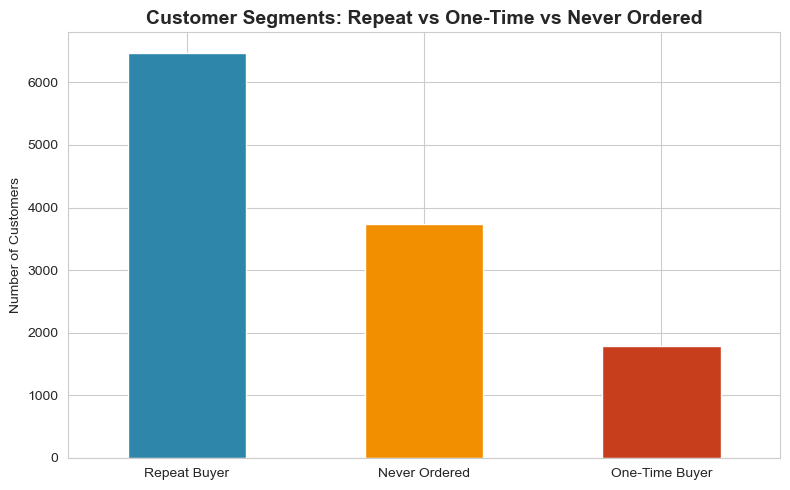

In [63]:
fig, ax = plt.subplots(figsize=(8,5))
segment_summary.plot(kind='bar', color=['#2E86AB','#F18F01','#C73E1D'], ax=ax)
ax.set_title('Customer Segments: Repeat vs One-Time vs Never Ordered', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Customers')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../dashboards/03_customer_segments.png', dpi=150)
plt.show()

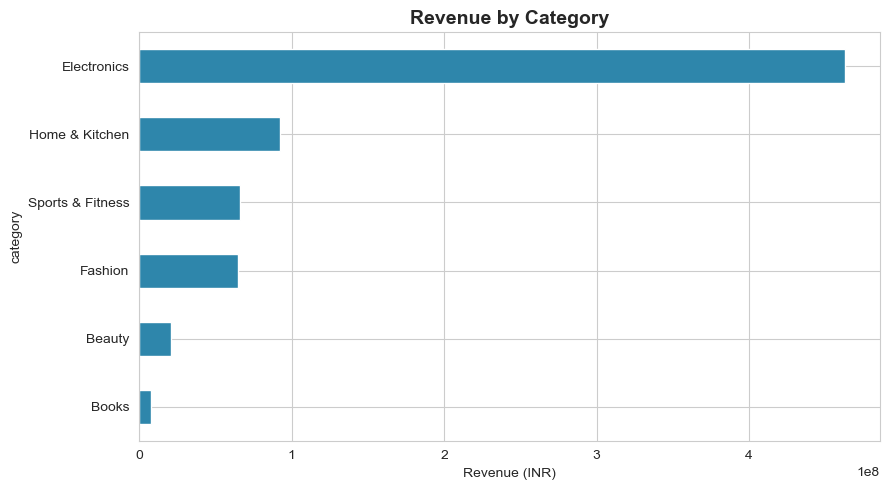

In [64]:
fig, ax = plt.subplots(figsize=(9,5))
category_revenue.plot(kind='barh', color='#2E86AB', ax=ax)
ax.set_title('Revenue by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue (INR)')
ax.invert_yaxis()  # sabse zyada wala upar dikhega
plt.tight_layout()
plt.savefig('../dashboards/04_category_revenue.png', dpi=150)
plt.show()

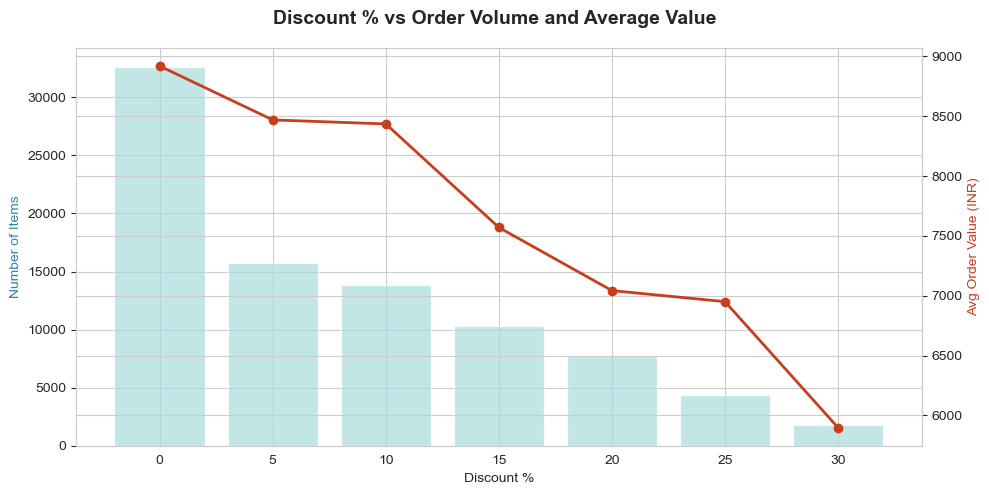

In [65]:
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.bar(discount_impact.index.astype(str), discount_impact['num_items'], color='#A8DADC', alpha=0.7, label='Number of Items')
ax1.set_xlabel('Discount %')
ax1.set_ylabel('Number of Items', color='#2E86AB')

ax2 = ax1.twinx()
ax2.plot(discount_impact.index.astype(str), discount_impact['avg_net_amount'], color='#C73E1D', marker='o', linewidth=2, label='Avg Order Value')
ax2.set_ylabel('Avg Order Value (INR)', color='#C73E1D')

fig.suptitle('Discount % vs Order Volume and Average Value', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../dashboards/05_discount_impact.png', dpi=150)
plt.show()

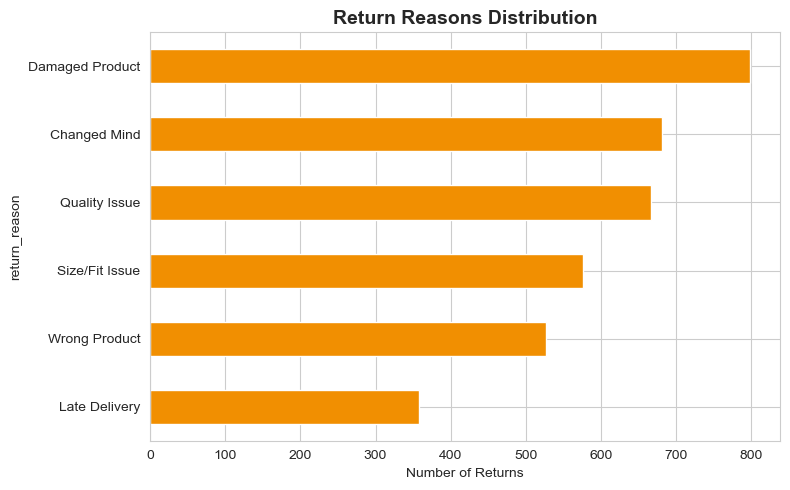

In [66]:
fig, ax = plt.subplots(figsize=(8,5))
return_reason_dist.sort_values().plot(kind='barh', color='#F18F01', ax=ax)
ax.set_title('Return Reasons Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Returns')
plt.tight_layout()
plt.savefig('../dashboards/06_return_reasons.png', dpi=150)
plt.show()